# Structural / Edge Enhancement — parameter study

**Phase 2** of the pipeline · BMDS2133 Image Processing · Assignment Mode A

This notebook determines the parameter values used later in
`02_processed_dataset.ipynb`. Three families of classical techniques are
implemented, benchmarked against a quantitative reference, and combined:

| Experiment | Technique family | Question |
|---|---|---|
| A | Gaussian filtering | How should the board be denoised before differentiation? |
| B | Edge detection | Which operator and threshold strategy recovers copper geometry best? |
| C | Morphological processing | Can post-processing repair broken contours without adding false edges? |
| D | Integration | Does the combined pipeline beat the textbook baseline? |

### How the comparison is made honest

No hand-drawn edge annotation exists for this dataset, and scoring one detector
against another would be circular. The reference edge map is therefore derived
from **colour**: Otsu's method on the HSV saturation channel separates copper
from the green solder mask, a second Otsu on the value channel isolates the
drill apertures, and the boundary of the resulting three-region label map is
the reference. Because it uses no intensity gradient, it is independent of
every operator under test.

Every defect class in this dataset — missing hole, mouse bite, open circuit,
short, spur, spurious copper — is a deviation of exactly this copper geometry,
so it is also the right target.

**Input:** the defect-free boards in `data/raw/PCB_USED/`.
Runs in roughly three minutes.

## 1 · Setup

In [1]:
# ---------------------------------------------------------------------
# Locate the project root.
#
# This notebook may sit in notebook/ or in notebook/<yourname>/, so the
# search walks upwards until it finds the folder containing "data".
# ---------------------------------------------------------------------
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "data").is_dir():
    raise SystemExit(
        "Could not find the project root (a folder containing 'data').\n"
        "Set it manually, for example:\n"
        "    PROJECT_ROOT = Path(r'C:/Users/you/PCB-Defect-Inspection')")

PCB_DIR = PROJECT_ROOT / "data" / "raw" / "PCB_USED"
RESULT_DIR = PROJECT_ROOT / "results" / "structural_enhancement"
FIGURE_DIR = RESULT_DIR / "figures"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if not PCB_DIR.is_dir():
    raise SystemExit(f"Reference boards not found at {PCB_DIR}")

BOARD_PATHS = sorted(p for p in PCB_DIR.iterdir()
                     if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"})

print("Project root :", PROJECT_ROOT)
print("Boards found :", len(BOARD_PATHS), "->", [p.stem for p in BOARD_PATHS])

Project root : e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection
Boards found : 10 -> ['01', '04', '05', '06', '07', '08', '09', '10', '11', '12']


In [2]:
import time
from dataclasses import dataclass, asdict, field
from typing import Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


@dataclass
class Config:
    """Every tunable value in one place.

    Nothing below is hardcoded inside a processing function, so a parameter
    sweep is just a matter of replacing one field and re-running.
    """
    # working resolution (None = full scale, but much slower)
    work_width: int = 1200

    # board localisation
    board_sat_min: int = 60
    board_val_min: int = 20
    board_close_ksize: int = 25
    board_inset: int = 6

    # reference (ground truth) map
    gt_median_ksize: int = 3
    gt_gradient_ksize: int = 3

    # smoothing
    gaussian_ksize: int = 5
    gaussian_sigma: float = 1.0
    median_ksize: int = 5
    bilateral_diameter: int = 7
    bilateral_sigma_colour: float = 50.0
    bilateral_sigma_space: float = 7.0

    # noise-adaptive filter selection
    impulse_threshold: float = 0.002
    impulse_escalate: float = 0.020
    sigma_low: float = 4.0
    sigma_high: float = 12.0

    # Canny
    canny_low: int = 50
    canny_high: int = 150
    canny_sigma: float = 0.33
    canny_ratio: float = 0.5
    canny_noise_gain: float = 7.0

    # morphological repair
    morph_shape: str = "ellipse"
    morph_close_size: int = 3
    morph_open_size: int = 0
    min_edge_area: int = 20

    # evaluation
    match_tolerance: int = 2
    fom_alpha: float = 1.0 / 9.0


CFG = Config()
RANDOM_SEED = 42
TIMING_REPEATS = 3
SWEEP_BOARDS = ["01", "05", "12"]   # subset used for the slower sweeps

np.random.seed(RANDOM_SEED)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

for k, v in asdict(CFG).items():
    print(f"{k:24s} {v}")

work_width               1200
board_sat_min            60
board_val_min            20
board_close_ksize        25
board_inset              6
gt_median_ksize          3
gt_gradient_ksize        3
gaussian_ksize           5
gaussian_sigma           1.0
median_ksize             5
bilateral_diameter       7
bilateral_sigma_colour   50.0
bilateral_sigma_space    7.0
impulse_threshold        0.002
impulse_escalate         0.02
sigma_low                4.0
sigma_high               12.0
canny_low                50
canny_high               150
canny_sigma              0.33
canny_ratio              0.5
canny_noise_gain         7.0
morph_shape              ellipse
morph_close_size         3
morph_open_size          0
min_edge_area            20
match_tolerance          2
fom_alpha                0.1111111111111111


## 2 · Basic utilities and board localisation

In [3]:
def to_binary(mask):
    """Force any mask-like array into a strict 0 / 255 uint8 form."""
    return np.where(mask > 0, 255, 0).astype(np.uint8)


def normalise_uint8(array):
    """Linearly rescale an arbitrary numeric array into 0-255."""
    array = array.astype(np.float64)
    lo, hi = float(array.min()), float(array.max())
    if hi - lo < 1e-12:
        return np.zeros(array.shape, np.uint8)
    return (((array - lo) / (hi - lo)) * 255.0).astype(np.uint8)


def resize_to_width(image, width):
    """Scale to a target width, preserving aspect ratio.

    INTER_AREA averages over the source footprint when downscaling, which
    suppresses aliasing of the fine copper traces.
    """
    if width is None or image.shape[1] == width:
        return image.copy()
    height = int(round(image.shape[0] * width / image.shape[1]))
    interp = cv2.INTER_AREA if width < image.shape[1] else cv2.INTER_CUBIC
    return cv2.resize(image, (width, height), interpolation=interp)


def structuring_element(shape="ellipse", size=3):
    """Create a structuring element.

    The shape is a genuine experimental variable here: a cross favours the
    axis-aligned tracks, an ellipse the circular pads and vias, and a
    rectangle is the most aggressive of the three.
    """
    shapes = {"rect": cv2.MORPH_RECT, "ellipse": cv2.MORPH_ELLIPSE,
              "cross": cv2.MORPH_CROSS}
    size = max(int(size), 1)
    if size % 2 == 0:
        size += 1
    return cv2.getStructuringElement(shapes[shape], (size, size))


def remove_small_components(binary, min_area=20, connectivity=8):
    """Discard connected components below an area threshold.

    On a Canny response the surviving small components are almost entirely
    noise fragments and solder-mask texture, whereas genuine copper
    boundaries form long connected contours.
    """
    if min_area <= 0:
        return binary.copy()
    count, labels, stats, _ = cv2.connectedComponentsWithStats(
        to_binary(binary), connectivity=connectivity)
    keep = np.zeros(count, bool)
    for label in range(1, count):
        keep[label] = stats[label, cv2.CC_STAT_AREA] >= min_area
    return to_binary(keep[labels])


def detect_board_roi(image_bgr, cfg=CFG):
    """Locate the board within the frame.

    The board carries a strongly saturated green solder mask whereas the
    surround is a desaturated grey, so thresholding saturation separates
    them far more reliably than any intensity rule, which would be defeated
    by the bright metallic pads.
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    saturation, value = hsv[:, :, 1], hsv[:, :, 2]

    board = to_binary((saturation >= cfg.board_sat_min) &
                      (value >= cfg.board_val_min))
    board = cv2.morphologyEx(board, cv2.MORPH_CLOSE,
                             structuring_element("rect", cfg.board_close_ksize))

    contours, _ = cv2.findContours(board, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0, 0, image_bgr.shape[1], image_bgr.shape[0]

    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    i = cfg.board_inset
    return x + i, y + i, max(w - 2 * i, 1), max(h - 2 * i, 1)


print("Utilities defined.")

Utilities defined.


## 3 · The reference structural map

A pixel is a structural edge wherever the region label changes. This is found
by comparing the dilation and the erosion of the label image: the two agree
only inside a homogeneous region, so any disagreement marks a boundary.

**Known bias.** Silkscreen legend and the matte texture of the solder mask are
genuine intensity edges that carry no copper geometry, so they are absent from
this reference and depress the measured precision of every method. The bias is
identical across methods and does not affect the ranking, but the absolute
precision values are a lower bound, not a defect-detection accuracy.

In [4]:
def region_label_map(image_bgr, cfg=CFG):
    """Partition the board into its three physically meaningful regions.

        0 = solder mask   green epoxy coating and tracks beneath it
        1 = drill / hole  plated through-holes and unlit pad centres
        2 = copper        exposed pads, vias and tinned tracks

    The split is entirely data-driven. Otsu on the saturation channel
    separates copper from solder mask; a second Otsu on the value channel
    *within the copper population only* separates the dark drill apertures
    from the bright metal around them. A short median filter then removes
    single-pixel label noise without displacing any boundary.
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    saturation, value = hsv[:, :, 1], hsv[:, :, 2]

    sat_threshold, _ = cv2.threshold(saturation, 0, 255,
                                     cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    copper = saturation < sat_threshold

    labels = np.zeros(saturation.shape, np.uint8)
    labels[copper] = 2

    if np.count_nonzero(copper) > 0:
        val_threshold, _ = cv2.threshold(
            value[copper].reshape(-1, 1), 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        labels[copper & (value < val_threshold)] = 1

    if cfg.gt_median_ksize > 1:
        labels = cv2.medianBlur(labels, cfg.gt_median_ksize)
    return labels


def reference_edge_map(image_bgr, cfg=CFG):
    """Derive the reference (ground truth) structural edge map."""
    labels = region_label_map(image_bgr, cfg)
    kernel = structuring_element("rect", cfg.gt_gradient_ksize)
    dilated = cv2.morphologyEx(labels, cv2.MORPH_DILATE, kernel)
    eroded = cv2.morphologyEx(labels, cv2.MORPH_ERODE, kernel)
    return to_binary(dilated != eroded)


def prepare_board(path, cfg=CFG):
    """Load one board and return every representation the notebook needs."""
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)

    working = resize_to_width(image, cfg.work_width)
    roi = detect_board_roi(working, cfg)
    x, y, w, h = roi
    board = working[y:y + h, x:x + w].copy()

    return {"id": Path(path).stem,
            "original_shape": image.shape[:2],
            "board": board,
            "gray": cv2.cvtColor(board, cv2.COLOR_BGR2GRAY),
            "labels": region_label_map(board, cfg),
            "reference": reference_edge_map(board, cfg)}


BOARDS = {}
for path in BOARD_PATHS:
    prepared = prepare_board(path)
    BOARDS[prepared["id"]] = prepared

pd.DataFrame([{
    "Board": b["id"],
    "Original (px)": f"{b['original_shape'][1]} x {b['original_shape'][0]}",
    "Working (px)": f"{b['board'].shape[1]} x {b['board'].shape[0]}",
    "Copper (%)": round(100 * np.mean(b["labels"] == 2), 2),
    "Drill (%)": round(100 * np.mean(b["labels"] == 1), 2),
    "Reference edge density (%)": round(
        100 * np.count_nonzero(b["reference"]) / b["reference"].size, 2),
} for b in BOARDS.values()])

,Board,Original (px),Working (px),Copper (%),Drill (%),Reference edge density (%)
0,01,3034 x 1586,1188 x 615,5.01,7.71,10.55
1,04,3056 x 2464,1169 x 956,5.17,5.29,7.50
2,05,2544 x 2156,1188 x 992,4.77,4.10,6.41
3,06,2868 x 2316,1188 x 957,4.59,4.23,6.45
4,07,2904 x 1921,1172 x 766,5.90,5.70,6.49
5,08,2759 x 2154,1170 x 898,15.43,10.86,19.42
6,09,2775 x 2159,1172 x 906,8.62,10.25,12.72
7,10,2240 x 2016,1140 x 1032,4.21,8.43,5.66
8,11,2282 x 2248,1143 x 1170,4.26,7.61,6.04
9,12,2529 x 2530,1188 x 1158,4.26,4.42,6.15


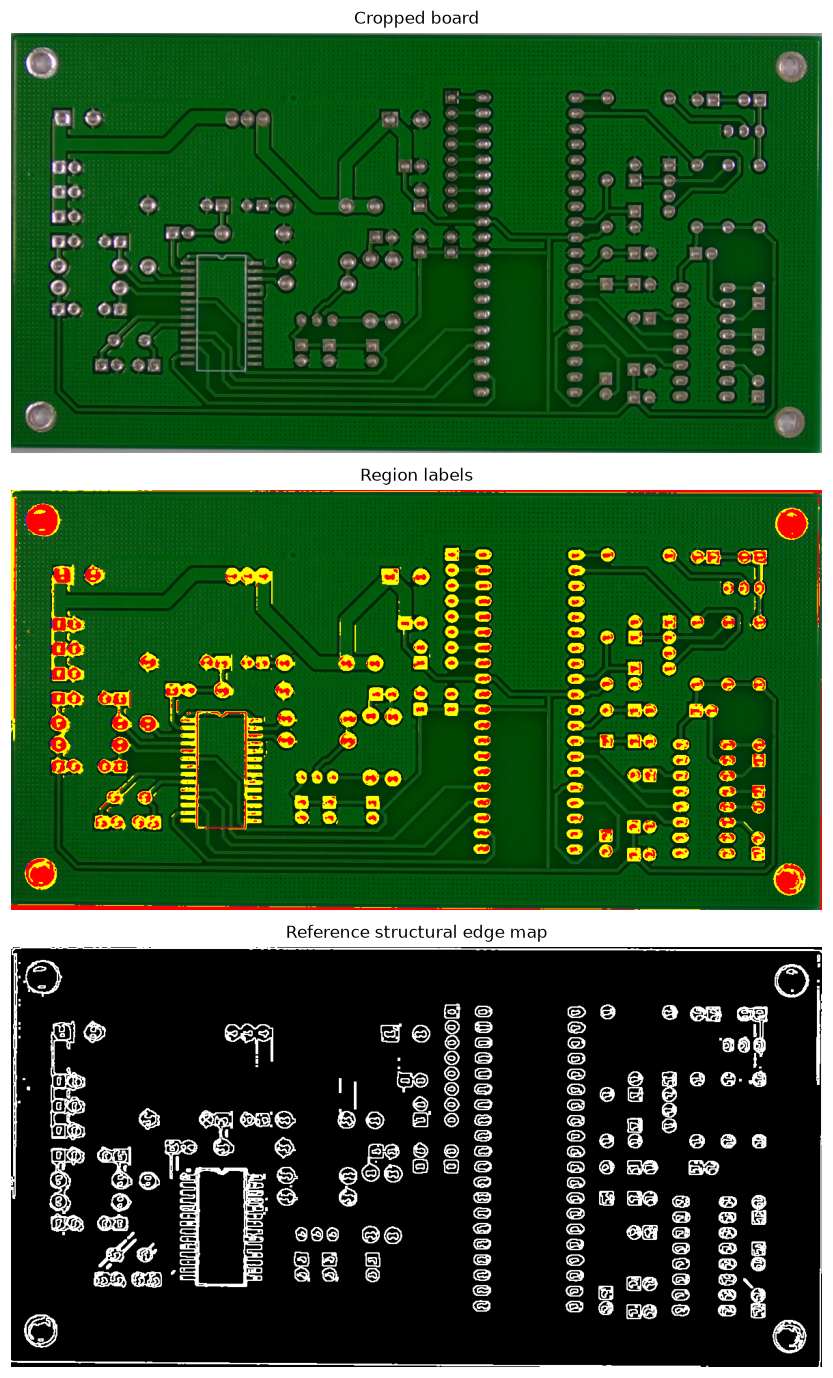

In [5]:
# ---------------------------------------------------------------------
# The reference map must be INSPECTED, not assumed: every metric in this
# notebook depends on it being correct.
# ---------------------------------------------------------------------
demo = BOARDS[SWEEP_BOARDS[0]]

overlay = demo["board"].copy()
overlay[demo["labels"] == 2] = (0, 0, 255)      # copper in red
overlay[demo["labels"] == 1] = (0, 255, 255)    # drill apertures in yellow

panels = [(cv2.cvtColor(demo["board"], cv2.COLOR_BGR2RGB), "Cropped board"),
          (cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB), "Region labels"),
          (demo["reference"], "Reference structural edge map")]

fig, axes = plt.subplots(len(panels), 1, figsize=(11, 4.2 * len(panels)))
for ax, (image, title) in zip(axes, panels):
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None)
    ax.set_title(title)
    ax.axis("off")
    ax.grid(False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_reference_map.png")
plt.show()

## 4 · Metrics

In [6]:
def mse(reference, test):
    return float(np.mean((reference.astype(np.float64)
                          - test.astype(np.float64)) ** 2))


def psnr(reference, test, data_range=255.0):
    error = mse(reference, test)
    return float("inf") if error <= 1e-12 else float(
        10.0 * np.log10((data_range ** 2) / error))


def ssim(reference, test, data_range=255.0, ksize=11, sigma=1.5):
    """Mean structural similarity (Wang et al., 2004).

    Implemented directly from the definition using Gaussian-weighted local
    statistics, so no dependency beyond OpenCV is introduced and the
    mechanism can be explained during assessment. Reported alongside PSNR
    because PSNR alone is a poor predictor of whether the fine copper
    structures survived filtering.
    """
    c1, c2 = (0.01 * data_range) ** 2, (0.03 * data_range) ** 2
    a, b = reference.astype(np.float64), test.astype(np.float64)
    window = (ksize, ksize)

    mu_a = cv2.GaussianBlur(a, window, sigma)
    mu_b = cv2.GaussianBlur(b, window, sigma)
    mu_a2, mu_b2, mu_ab = mu_a ** 2, mu_b ** 2, mu_a * mu_b

    sigma_a = cv2.GaussianBlur(a * a, window, sigma) - mu_a2
    sigma_b = cv2.GaussianBlur(b * b, window, sigma) - mu_b2
    sigma_ab = cv2.GaussianBlur(a * b, window, sigma) - mu_ab

    numerator = (2 * mu_ab + c1) * (2 * sigma_ab + c2)
    denominator = (mu_a2 + mu_b2 + c1) * (sigma_a + sigma_b + c2)
    return float(np.mean(numerator / denominator))


def edge_preservation_index(reference, filtered):
    """Correlation of Laplacian responses; 1 means detail fully retained.

    This is the metric that exposes the central trade-off of Gaussian
    filtering: increasing sigma improves PSNR while progressively
    destroying the boundaries the inspection stage depends upon.
    """
    a = cv2.Laplacian(reference.astype(np.float64), cv2.CV_64F)
    b = cv2.Laplacian(filtered.astype(np.float64), cv2.CV_64F)
    a, b = a - a.mean(), b - b.mean()
    denominator = np.sqrt(np.sum(a ** 2) * np.sum(b ** 2))
    return 0.0 if denominator < 1e-12 else float(np.sum(a * b) / denominator)


def edge_prf(predicted, ground_truth, tolerance=2):
    """Precision, recall and F1 with a spatial tolerance.

    Requiring exact pixel coincidence would penalise every detector for
    sub-pixel localisation differences that are irrelevant to inspection,
    so both maps are dilated before matching, as in the standard boundary
    benchmark protocol.
    """
    pred, truth = to_binary(predicted) > 0, to_binary(ground_truth) > 0

    if tolerance > 0:
        kernel = structuring_element("ellipse", 2 * tolerance + 1)
        pred_dilated = cv2.dilate(to_binary(pred), kernel) > 0
        truth_dilated = cv2.dilate(to_binary(truth), kernel) > 0
    else:
        pred_dilated, truth_dilated = pred, truth

    true_positive = np.count_nonzero(pred & truth_dilated)
    matched_truth = np.count_nonzero(truth & pred_dilated)
    n_pred, n_truth = int(np.count_nonzero(pred)), int(np.count_nonzero(truth))

    precision = true_positive / n_pred if n_pred else 0.0
    recall = matched_truth / n_truth if n_truth else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if precision + recall > 0 else 0.0)

    return {"precision": float(precision), "recall": float(recall),
            "f1": float(f1), "n_predicted": n_pred, "n_truth": n_truth}


def pratt_fom(predicted, ground_truth, alpha=1.0 / 9.0):
    """Pratt's Figure of Merit for edge localisation accuracy.

        FOM = 1/max(N_detected, N_ideal) * sum_i 1 / (1 + alpha * d_i^2)

    Unlike F1, the score degrades smoothly with displacement, so it tells a
    detector that is merely imprecise apart from one placing edges in
    entirely the wrong location.
    """
    pred, truth = to_binary(predicted), to_binary(ground_truth)
    n_pred, n_truth = np.count_nonzero(pred), np.count_nonzero(truth)
    if n_pred == 0 or n_truth == 0:
        return 0.0

    distance = cv2.distanceTransform(cv2.bitwise_not(truth), cv2.DIST_L2, 3)
    d = distance[pred > 0].astype(np.float64)
    return float(np.sum(1.0 / (1.0 + alpha * d ** 2)) / max(n_pred, n_truth))


def edge_continuity(binary, connectivity=8):
    """Summarise how fragmented an edge map is.

    For a fixed quantity of edge pixels, fewer and longer components mean
    better contour continuity. Normalising per thousand edge pixels stops a
    detector being rewarded simply for producing fewer edges.
    """
    image = to_binary(binary)
    count, _, stats, _ = cv2.connectedComponentsWithStats(image, connectivity)
    n_components = max(count - 1, 0)
    total = int(np.count_nonzero(image))

    if n_components == 0:
        return {"n_components": 0, "edge_pixels": 0,
                "mean_component_size": 0.0, "fragmentation": 0.0}

    areas = stats[1:, cv2.CC_STAT_AREA]
    return {"n_components": int(n_components), "edge_pixels": total,
            "mean_component_size": float(areas.mean()),
            "fragmentation": float(1000.0 * n_components / total)}


def thin_edge_map(binary):
    """Reduce an edge map to unit width, for thickness-invariant comparison."""
    image = to_binary(binary)
    skeleton = np.zeros_like(image)
    kernel = structuring_element("cross", 3)
    for _ in range(200):
        opened = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
        skeleton = cv2.bitwise_or(skeleton, cv2.subtract(image, opened))
        image = cv2.erode(image, kernel)
        if cv2.countNonZero(image) == 0:
            break
    return skeleton


def evaluate_edge_map(predicted, ground_truth, cfg=CFG,
                      normalise_thickness=False):
    """All edge quality metrics in one call.

    normalise_thickness thins both maps to unit width first. This matters
    when comparing operators whose output thickness differs: the reference
    is about two pixels wide, so a thick response overlaps it more readily
    and scores higher for that reason alone rather than because it
    localises boundaries better.
    """
    if normalise_thickness:
        predicted = thin_edge_map(predicted)
        ground_truth = thin_edge_map(ground_truth)

    result = {}
    result.update(edge_prf(predicted, ground_truth, cfg.match_tolerance))
    result["pratt_fom"] = pratt_fom(predicted, ground_truth, cfg.fom_alpha)
    result.update(edge_continuity(predicted))
    result["edge_density"] = float(
        np.count_nonzero(to_binary(predicted)) / predicted.size)
    return result


def time_call(function, *args, repeats=3, **kwargs):
    """Return the result and the BEST time in ms.

    The minimum is reported rather than the mean, being the measurement
    least contaminated by unrelated operating system activity.
    """
    best, output = float("inf"), None
    for _ in range(max(repeats, 1)):
        start = time.perf_counter()
        output = function(*args, **kwargs)
        best = min(best, time.perf_counter() - start)
    return output, best * 1000.0


print("Metrics defined.")

Metrics defined.


## 5 · Experiment A — Gaussian filtering

Degrading a clean board with a *known* noise process is what makes the
comparison quantitative: the undegraded image then acts as ground truth for
PSNR and SSIM, which is otherwise unavailable.

In [7]:
# --- controlled noise simulation -------------------------------------
def add_gaussian_noise(gray, sigma=15.0, seed=RANDOM_SEED):
    """Zero-mean additive white Gaussian noise."""
    rng = np.random.default_rng(seed)
    return np.clip(gray.astype(np.float64) + rng.normal(0, sigma, gray.shape),
                   0, 255).astype(np.uint8)


def add_salt_pepper_noise(gray, amount=0.02, salt_ratio=0.5,
                          seed=RANDOM_SEED):
    """Impulse noise: a proportion of pixels forced to black or white."""
    rng = np.random.default_rng(seed)
    noisy = gray.copy()
    draw = rng.random(gray.shape)
    noisy[draw < amount * salt_ratio] = 255
    noisy[(draw >= amount * salt_ratio) & (draw < amount)] = 0
    return noisy


def add_speckle_noise(gray, sigma=0.15, seed=RANDOM_SEED):
    """Multiplicative noise, characteristic of uneven illumination."""
    rng = np.random.default_rng(seed)
    return np.clip(gray.astype(np.float64) * (1 + rng.normal(0, sigma, gray.shape)),
                   0, 255).astype(np.uint8)


# --- Gaussian kernel construction ------------------------------------
def gaussian_kernel_1d(ksize, sigma):
    """Normalised 1-D Gaussian kernel.

    Written out rather than calling cv2.getGaussianKernel so that the
    sampled form and the normalisation to unit sum - which is what makes
    the filter preserve mean intensity - are visible.
    """
    if ksize % 2 == 0 or ksize < 1:
        raise ValueError("Kernel size must be a positive odd integer.")
    radius = ksize // 2
    x = np.arange(-radius, radius + 1, dtype=np.float64)
    kernel = np.exp(-(x ** 2) / (2.0 * sigma ** 2))
    return kernel / kernel.sum()


def gaussian_blur_separable(gray, ksize=5, sigma=1.0):
    """Gaussian smoothing as two 1-D passes.

    The 2-D Gaussian is separable, so the full kernel is the outer product
    of two identical 1-D kernels. Exploiting that reduces the cost per
    pixel from O(k^2) to O(2k).
    """
    kernel = gaussian_kernel_1d(ksize, sigma).astype(np.float32)
    horizontal = cv2.filter2D(gray, cv2.CV_32F, kernel.reshape(1, -1),
                              borderType=cv2.BORDER_REFLECT_101)
    vertical = cv2.filter2D(horizontal, cv2.CV_32F, kernel.reshape(-1, 1),
                            borderType=cv2.BORDER_REFLECT_101)
    return np.clip(vertical, 0, 255).astype(np.uint8)


def smooth(gray, method="gaussian", cfg=CFG, **over):
    """Dispatch to one of the candidate smoothing operators."""
    method = method.lower()
    if method == "adaptive":
        chosen, params = select_smoother(gray, cfg)
        params.update(over)
        return smooth(gray, chosen, cfg, **params)
    if method == "none":
        return gray.copy()
    if method == "box":
        k = int(over.get("ksize", cfg.gaussian_ksize))
        return cv2.blur(gray, (k, k))
    if method == "gaussian":
        k = int(over.get("ksize", cfg.gaussian_ksize))
        s = float(over.get("sigma", cfg.gaussian_sigma))
        return cv2.GaussianBlur(gray, (k, k), s,
                                borderType=cv2.BORDER_REFLECT_101)
    if method == "gaussian_manual":
        return gaussian_blur_separable(gray,
                                       int(over.get("ksize", cfg.gaussian_ksize)),
                                       float(over.get("sigma", cfg.gaussian_sigma)))
    if method == "median":
        return cv2.medianBlur(gray, int(over.get("ksize", cfg.median_ksize)))
    if method == "bilateral":
        return cv2.bilateralFilter(
            gray, int(over.get("diameter", cfg.bilateral_diameter)),
            float(over.get("sigma_colour", cfg.bilateral_sigma_colour)),
            float(over.get("sigma_space", cfg.bilateral_sigma_space)))
    if method == "nlm":
        return cv2.fastNlMeansDenoising(gray, None,
                                        float(over.get("strength", 7.0)), 7, 21)
    raise ValueError(f"Unknown smoothing method: {method}")


print("Noise and smoothing functions defined.")

Noise and smoothing functions defined.


### A.1 Kernel construction and separability

In [8]:
kernel_1d = gaussian_kernel_1d(5, 1.0)
print("1-D kernel (k=5, sigma=1.0):")
print(np.round(kernel_1d, 5), " sum =", round(kernel_1d.sum(), 6))
print("\n2-D kernel as the outer product:")
print(np.round(np.outer(kernel_1d, kernel_1d), 5))

test_gray = demo["gray"]
kernel_2d = np.outer(kernel_1d, kernel_1d).astype(np.float32)

direct, direct_ms = time_call(cv2.filter2D, test_gray, cv2.CV_32F, kernel_2d,
                              repeats=TIMING_REPEATS)
separable, separable_ms = time_call(gaussian_blur_separable, test_gray, 5, 1.0,
                                    repeats=TIMING_REPEATS)
opencv, opencv_ms = time_call(cv2.GaussianBlur, test_gray, (5, 5), 1.0,
                              repeats=TIMING_REPEATS)

difference = np.max(np.abs(np.clip(direct, 0, 255).astype(np.int16)
                           - separable.astype(np.int16)))

print(f"\nMax difference, direct vs separable : {difference} grey level(s)")
print(f"Direct 2-D convolution : {direct_ms:7.2f} ms")
print(f"Separable (two 1-D)    : {separable_ms:7.2f} ms  "
      f"({direct_ms / separable_ms:.2f}x faster)")
print(f"cv2.GaussianBlur       : {opencv_ms:7.2f} ms")

1-D kernel (k=5, sigma=1.0):
[0.05449 0.2442  0.40262 0.2442  0.05449]  sum = 1.0

2-D kernel as the outer product:
[[0.00297 0.01331 0.02194 0.01331 0.00297]
 [0.01331 0.05963 0.09832 0.05963 0.01331]
 [0.02194 0.09832 0.1621  0.09832 0.02194]
 [0.01331 0.05963 0.09832 0.05963 0.01331]
 [0.00297 0.01331 0.02194 0.01331 0.00297]]

Max difference, direct vs separable : 1 grey level(s)
Direct 2-D convolution :    9.14 ms
Separable (two 1-D)    :    3.47 ms  (2.63x faster)
cv2.GaussianBlur       :    0.19 ms


### A.2 Parameter sweep — kernel size and sigma

The edge preservation index is reported alongside PSNR and SSIM because PSNR
alone cannot distinguish "noise removed" from "fine copper tracks destroyed".

In [9]:
KERNEL_SIZES = [3, 5, 7, 9, 11, 15]
SIGMAS = [0.5, 1.0, 1.5, 2.0, 3.0]
NOISE_SIGMA = 15.0

records = []
for board_id in SWEEP_BOARDS:
    clean = BOARDS[board_id]["gray"]
    noisy = add_gaussian_noise(clean, NOISE_SIGMA)
    for ksize in KERNEL_SIZES:
        for sigma in SIGMAS:
            filtered, elapsed = time_call(smooth, noisy, "gaussian", CFG,
                                          ksize=ksize, sigma=sigma,
                                          repeats=TIMING_REPEATS)
            records.append({"board": board_id, "ksize": ksize, "sigma": sigma,
                            "PSNR (dB)": psnr(clean, filtered),
                            "SSIM": ssim(clean, filtered),
                            "EPI": edge_preservation_index(clean, filtered),
                            "time (ms)": elapsed})

sweep = (pd.DataFrame(records).groupby(["ksize", "sigma"])
         .mean(numeric_only=True).round(4).reset_index())
sweep.to_csv(RESULT_DIR / "A2_gaussian_parameter_sweep.csv", index=False)
sweep.sort_values("SSIM", ascending=False).head(10)

,ksize,sigma,PSNR (dB),SSIM,EPI,time (ms)
12,7,1.5,31.0506,0.8360,0.3540,0.4003
7,5,1.5,31.4134,0.8349,0.3165,0.3025
22,11,1.5,30.9371,0.8349,0.3475,0.3978
27,15,1.5,30.9371,0.8349,0.3475,0.5936
17,9,1.5,30.9371,0.8349,0.3475,0.4305
11,7,1.0,32.0191,0.8293,0.4414,0.3691
16,9,1.0,32.0191,0.8293,0.4414,0.4556
21,11,1.0,32.0191,0.8293,0.4414,0.3890
26,15,1.0,32.0191,0.8293,0.4414,0.6035
6,5,1.0,32.0307,0.8271,0.4426,0.3109


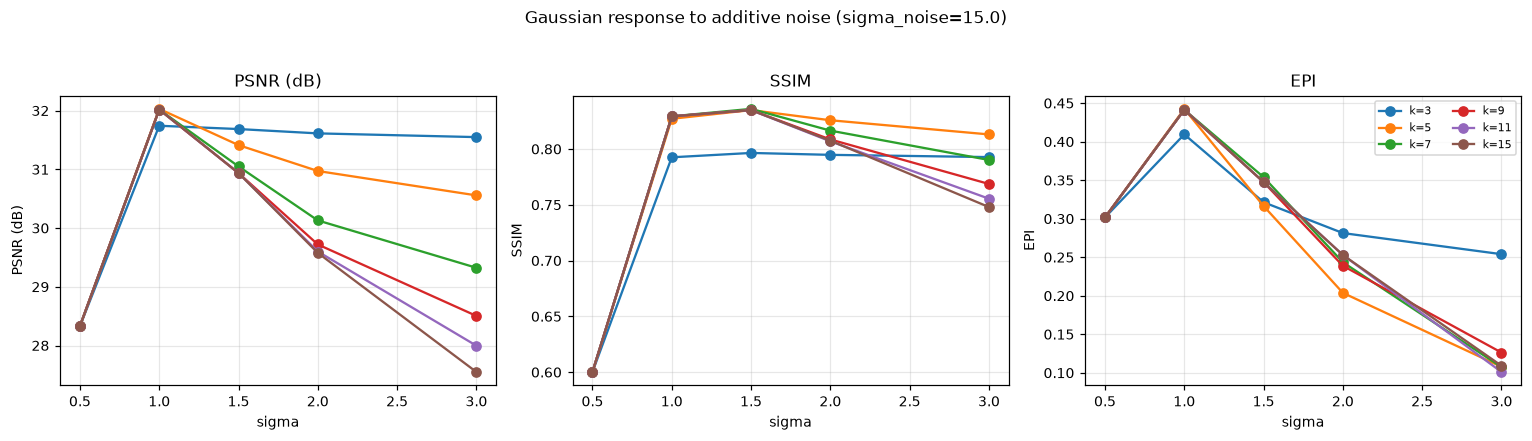

Highest SSIM at k=7, sigma=1.5: SSIM=0.8360, PSNR=31.05 dB, EPI=0.3540


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, column in zip(axes, ["PSNR (dB)", "SSIM", "EPI"]):
    pivot = sweep.pivot(index="sigma", columns="ksize", values=column)
    for ksize in pivot.columns:
        ax.plot(pivot.index, pivot[ksize], marker="o", label=f"k={ksize}")
    ax.set_xlabel("sigma")
    ax.set_ylabel(column)
    ax.set_title(column)
axes[-1].legend(fontsize=7, ncol=2)
plt.suptitle(f"Gaussian response to additive noise (sigma_noise={NOISE_SIGMA})",
             y=1.04)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "A2_gaussian_sweep.png")
plt.show()

best = sweep.loc[sweep["SSIM"].idxmax()]
print(f"Highest SSIM at k={int(best['ksize'])}, sigma={best['sigma']}: "
      f"SSIM={best['SSIM']:.4f}, PSNR={best['PSNR (dB)']:.2f} dB, "
      f"EPI={best['EPI']:.4f}")

### A.3 Gaussian against the alternatives

Filters must be compared at **matched smoothing strength**. A box filter of
width `k` has variance `(k²−1)/12`, so at `k=5` the equivalent Gaussian has
`sigma = 1.414`. Comparing a box filter against a much weaker Gaussian would
attribute to the kernel *shape* a difference that is really one of strength,
so both settings are included.

In [11]:
NOISE_CASES = [
    ("clean",            None,                  {}),
    ("gaussian s=10",    add_gaussian_noise,    {"sigma": 10}),
    ("gaussian s=25",    add_gaussian_noise,    {"sigma": 25}),
    ("salt & pepper 1%", add_salt_pepper_noise, {"amount": 0.01}),
    ("salt & pepper 5%", add_salt_pepper_noise, {"amount": 0.05}),
    ("speckle s=0.15",   add_speckle_noise,     {"sigma": 0.15}),
]

BOX_KSIZE = 5
MATCHED_SIGMA = float(np.sqrt((BOX_KSIZE ** 2 - 1) / 12))

SMOOTHERS = [
    ("none",             "none",      {}),
    ("box",              "box",       {"ksize": BOX_KSIZE}),
    ("gaussian s=1.0",   "gaussian",  {"ksize": BOX_KSIZE, "sigma": 1.0}),
    ("gaussian matched", "gaussian",  {"ksize": BOX_KSIZE, "sigma": MATCHED_SIGMA}),
    ("median",           "median",    {"ksize": BOX_KSIZE}),
    ("bilateral",        "bilateral", {}),
    ("nlm",              "nlm",       {"strength": 7.0}),
]

print(f"Box width {BOX_KSIZE} matches a Gaussian of sigma={MATCHED_SIGMA:.3f}")

Box width 5 matches a Gaussian of sigma=1.414


## 6 · Experiment B — Edge detection

### Threshold strategies

Canny compares its thresholds against **gradient magnitude**, not intensity, so
deriving them from the intensity histogram is dimensionally inconsistent
however common the practice is. The `gradient` strategy corrects that, and
`adaptive` adds a noise floor:

For additive noise of standard deviation `sigma`, the Sobel kernel's squared
weights sum to 12, so the noise component of each directional derivative has
standard deviation `sqrt(12)*sigma`. Placing the upper threshold about two
standard deviations above that scale gives

```
high >= 2 * sqrt(12) * sigma  ~=  7 * sigma
```

The constant is **derived, not tuned**. Taking the maximum of this floor and
the gradient-domain Otsu threshold leaves the floor inactive on a clean board
and lets it take over only once noise-induced gradients rival genuine ones.

In [12]:
def edge_roberts(gray, l2=True):
    """Roberts cross: 2x2 diagonal differences, minimal support."""
    kx = np.array([[1, 0], [0, -1]], np.float32)
    ky = np.array([[0, 1], [-1, 0]], np.float32)
    gx = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, kx)
    gy = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, ky)
    return cv2.magnitude(gx, gy) if l2 else np.abs(gx) + np.abs(gy)


def edge_prewitt(gray, l2=True):
    """Prewitt: 3x3 difference with uniform (box) smoothing."""
    kx = np.array([[-1, 0, 1]] * 3, np.float32)
    ky = kx.T.copy()
    gx = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, kx)
    gy = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, ky)
    return cv2.magnitude(gx, gy) if l2 else np.abs(gx) + np.abs(gy)


def edge_sobel(gray, ksize=3, l2=True):
    """Sobel: difference weighted by a binomial smoothing kernel."""
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=ksize)
    return cv2.magnitude(gx, gy) if l2 else np.abs(gx) + np.abs(gy)


def edge_scharr(gray, l2=True):
    """Scharr: 3x3 kernel optimised for rotational symmetry."""
    gx = cv2.Scharr(gray, cv2.CV_32F, 1, 0)
    gy = cv2.Scharr(gray, cv2.CV_32F, 0, 1)
    return cv2.magnitude(gx, gy) if l2 else np.abs(gx) + np.abs(gy)


def edge_log(gray, ksize=5, sigma=1.4):
    """Laplacian of Gaussian (Marr-Hildreth).

    The image is smoothed before the second derivative is taken, because
    the Laplacian alone is intolerably noise-sensitive. Edges are zero
    crossings; their strength is estimated from the local range.
    """
    laplacian = cv2.Laplacian(cv2.GaussianBlur(gray, (ksize, ksize), sigma),
                              cv2.CV_32F, ksize=3)
    kernel = np.ones((3, 3), np.uint8)
    local_min = cv2.erode(laplacian, kernel)
    local_max = cv2.dilate(laplacian, kernel)
    crossing = ((local_min < 0) & (local_max > 0)).astype(np.float32)
    return crossing * (local_max - local_min)


# --- noise estimation, used by both the filter selector and Canny ------
_IMMERKAER = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], np.float32)


def estimate_noise_sigma(gray):
    """Immerkaer's (1996) estimator: noise sigma without a clean reference.

    The mask annihilates any locally planar intensity surface, so its
    response is dominated by noise rather than by structure. One
    convolution, cheap enough to run per frame.
    """
    h, w = gray.shape[:2]
    if h < 3 or w < 3:
        return 0.0
    response = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, _IMMERKAER,
                            borderType=cv2.BORDER_REFLECT_101)
    return float(np.sqrt(np.pi / 2) / (6.0 * (w - 2) * (h - 2))
                 * np.sum(np.abs(response)))


def estimate_impulse_ratio(gray, deviation=80, extreme_margin=8):
    """Proportion of pixels corrupted by impulse noise.

    A salt-and-pepper pixel has two signatures at once: it sits at an
    extreme of the range AND departs sharply from its local median.
    Requiring both separates impulse noise from strong Gaussian noise,
    which produces large deviations but rarely saturates.
    """
    median = cv2.medianBlur(gray, 3)
    deviation_map = np.abs(gray.astype(np.int16) - median.astype(np.int16))
    extreme = (gray <= extreme_margin) | (gray >= 255 - extreme_margin)
    return float(np.mean((deviation_map > deviation) & extreme))


def select_smoother(gray, cfg=CFG):
    """Choose a smoothing operator from the measured noise.

        impulse above limit -> median      rank filtering rejects outliers
        sigma below low     -> none        board already clean; do not blur
        sigma above high    -> bilateral   edge-preserving weighting needed
        otherwise           -> gaussian    optimal linear response, cheapest
    """
    impulse = estimate_impulse_ratio(gray)
    sigma = estimate_noise_sigma(gray)

    if impulse > cfg.impulse_threshold:
        # A 7x7 window removes denser impulses but visibly rounds pad
        # corners, so escalation sits an order of magnitude above detection.
        return "median", {"ksize": 5 if impulse < cfg.impulse_escalate else 7}
    if sigma < cfg.sigma_low:
        return "none", {}
    if sigma > cfg.sigma_high:
        return "bilateral", {"diameter": cfg.bilateral_diameter,
                             "sigma_colour": max(cfg.bilateral_sigma_colour,
                                                 2.0 * sigma),
                             "sigma_space": cfg.bilateral_sigma_space}
    return "gaussian", {"ksize": cfg.gaussian_ksize,
                        "sigma": float(np.clip(sigma / 10.0, 0.6, 2.0))}


def gradient_otsu_threshold(gray):
    """Otsu's threshold on the Sobel gradient magnitude.

    The magnitude is CLIPPED rather than rescaled, so the threshold stays
    in the units cv2.Canny uses internally and can be passed to it
    directly. Rescaling would break that, since the scale factor varies
    from image to image.
    """
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    magnitude = np.clip(cv2.magnitude(gx, gy), 0, 255).astype(np.uint8)
    threshold, _ = cv2.threshold(magnitude, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return float(threshold)


def canny_thresholds(gray, strategy="adaptive", cfg=CFG, **over):
    """Hysteresis thresholds under one of six strategies."""
    ratio = float(over.get("ratio", cfg.canny_ratio))

    if strategy == "fixed":
        low, high = (int(over.get("low", cfg.canny_low)),
                     int(over.get("high", cfg.canny_high)))
    elif strategy == "median":
        s = float(over.get("sigma", cfg.canny_sigma))
        m = float(np.median(gray))
        low, high = int(max(0, (1 - s) * m)), int(min(255, (1 + s) * m))
    elif strategy == "otsu":
        value, _ = cv2.threshold(gray, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        high = int(value)
        low = int(ratio * high)
    elif strategy == "percentile":
        keep = float(over.get("keep", 0.10))
        high = int(np.percentile(gray, 100 * (1 - keep)))
        low = int(ratio * high)
    elif strategy == "gradient":
        high = int(gradient_otsu_threshold(gray))
        low = int(ratio * high)
    elif strategy == "adaptive":
        # The floor must reflect the noise that ENTERED the system, so an
        # estimate measured on the unfiltered input is passed in. Measuring
        # it here would read the residual of an already-smoothed image, and
        # the floor would never engage.
        gain = float(over.get("noise_gain", cfg.canny_noise_gain))
        sigma = over.get("noise_sigma")
        if sigma is None:
            sigma = estimate_noise_sigma(gray)
        high = int(max(gradient_otsu_threshold(gray), gain * float(sigma)))
        low = int(ratio * high)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    low = int(np.clip(low, 0, 254))
    high = int(np.clip(max(high, low + 1), 1, 255))
    return low, high


def edge_canny(gray, cfg=CFG, strategy="adaptive", **over):
    """Canny with the selected threshold strategy."""
    low, high = canny_thresholds(gray, strategy, cfg, **over)
    return cv2.Canny(gray, low, high, apertureSize=3, L2gradient=True)


def detect_edges(gray, method="canny", cfg=CFG, **over):
    """Binary edge map plus the underlying gradient magnitude.

    Gradient operators are binarised with Otsu on their OWN magnitude
    response, so no operator is advantaged by a hand-tuned threshold.
    """
    if method == "canny":
        return to_binary(edge_canny(gray, cfg, **over)), edge_sobel(gray)

    over.pop("noise_sigma", None)   # only meaningful to the Canny branch
    operators = {"roberts": lambda: edge_roberts(gray),
                 "prewitt": lambda: edge_prewitt(gray),
                 "sobel": lambda: edge_sobel(gray, int(over.get("ksize", 3))),
                 "scharr": lambda: edge_scharr(gray),
                 "log": lambda: edge_log(gray)}
    if method not in operators:
        raise ValueError(f"Unknown edge method: {method}")

    magnitude = operators[method]()
    _, edges = cv2.threshold(normalise_uint8(magnitude), 0, 255,
                             cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return to_binary(edges), magnitude


print("Edge operators defined.")
print("Clean board thresholds :", canny_thresholds(demo["gray"], "adaptive"))
noisy_demo = add_gaussian_noise(demo["gray"], 25)
print("Noisy board thresholds :",
      canny_thresholds(noisy_demo, "adaptive",
                       noise_sigma=estimate_noise_sigma(noisy_demo)),
      f"(sigma={estimate_noise_sigma(noisy_demo):.1f})")

Edge operators defined.
Clean board thresholds : (46, 93)
Noisy board thresholds : (85, 171) (sigma=24.5)


## 7 · Experiment C — Morphological processing

Canny returns thin contours that break where a track's contrast against the
solder mask is weak, plus many tiny fragments from surface texture. Closing
bridges the breaks; area filtering removes the fragments.

**Order matters.** Closing must come first: running the area filter first would
delete the very fragments that closing would have merged into a valid contour.

In [13]:
def repair_edge_map(binary, cfg=CFG, **over):
    """Closing, then area filtering, then an optional opening."""
    shape = over.get("shape", cfg.morph_shape)
    close_size = int(over.get("close_size", cfg.morph_close_size))
    open_size = int(over.get("open_size", cfg.morph_open_size))
    min_area = int(over.get("min_area", cfg.min_edge_area))

    repaired = to_binary(binary)

    # Dilation joins fragments separated by less than the element width;
    # the following erosion restores the original thickness.
    if close_size > 1:
        repaired = cv2.morphologyEx(repaired, cv2.MORPH_CLOSE,
                                    structuring_element(shape, close_size))
    if min_area > 0:
        repaired = remove_small_components(repaired, min_area)
    if open_size > 1:
        repaired = cv2.morphologyEx(repaired, cv2.MORPH_OPEN,
                                    structuring_element(shape, open_size))
    return repaired


def morphological_skeleton(binary, shape="cross", size=3, max_iterations=200):
    """Lantuejoul skeleton: unit-width centrelines.

    At each step the opening is subtracted from the current image,
    contributing the pixels the element cannot fit inside, and the image is
    eroded. The union of those contributions is the skeleton.

    Written out because cv2.ximgproc.thinning lives in the contrib package,
    which cannot be assumed present on every marker's machine.
    """
    image = to_binary(binary)
    skeleton = np.zeros_like(image)
    kernel = structuring_element(shape, size)
    for _ in range(max_iterations):
        opened = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
        skeleton = cv2.bitwise_or(skeleton, cv2.subtract(image, opened))
        image = cv2.erode(image, kernel)
        if cv2.countNonZero(image) == 0:
            break
    return skeleton


# Hit-or-miss kernels matching a line ending in each of eight directions.
# 1 requires foreground, -1 requires background, 0 is don't-care.
_ENDPOINTS = [
    np.array([[-1, -1, -1], [-1, 1, -1], [0, 1, 0]], np.int8),
    np.array([[-1, -1, -1], [-1, 1, 0], [-1, 0, 1]], np.int8),
    np.array([[-1, -1, -1], [-1, 1, 1], [-1, -1, -1]], np.int8),
    np.array([[-1, 0, 1], [-1, 1, 0], [-1, -1, -1]], np.int8),
    np.array([[0, 1, 0], [-1, 1, -1], [-1, -1, -1]], np.int8),
    np.array([[1, 0, -1], [0, 1, -1], [-1, -1, -1]], np.int8),
    np.array([[-1, -1, -1], [1, 1, -1], [-1, -1, -1]], np.int8),
    np.array([[-1, -1, -1], [0, 1, -1], [1, 0, -1]], np.int8),
]


def prune_spurs(binary, iterations=3):
    """Remove short spurious branches from a thinned map.

    Each pass finds line endpoints with the hit-or-miss transform and
    deletes them, shortening every free-ended branch while leaving closed
    contours intact.
    """
    image = to_binary(binary)
    for _ in range(max(iterations, 0)):
        endpoints = np.zeros_like(image)
        for kernel in _ENDPOINTS:
            endpoints = cv2.bitwise_or(
                endpoints, cv2.morphologyEx(image, cv2.MORPH_HITMISS, kernel))
        if cv2.countNonZero(endpoints) == 0:
            break
        image = cv2.subtract(image, endpoints)
    return image


print("Morphological functions defined.")

Morphological functions defined.


### C.1 Ablation of the repair sequence

In [14]:
REPAIR_VARIANTS = [
    ("raw Canny",              {"close_size": 0, "min_area": 0,  "open_size": 0}),
    ("+ closing",              {"close_size": 3, "min_area": 0,  "open_size": 0}),
    ("+ area filter",          {"close_size": 0, "min_area": 20, "open_size": 0}),
    ("+ closing, area filter", {"close_size": 3, "min_area": 20, "open_size": 0}),
    ("+ closing, area, open",  {"close_size": 3, "min_area": 20, "open_size": 3}),
]

records = []
for board_id, board in BOARDS.items():
    sigma = estimate_noise_sigma(board["gray"])
    prepared = smooth(board["gray"], "gaussian", CFG)
    raw_edges = edge_canny(prepared, CFG, noise_sigma=sigma)

    for label, over in REPAIR_VARIANTS:
        scores = evaluate_edge_map(repair_edge_map(raw_edges, CFG, **over),
                                   board["reference"], CFG)
        records.append({"board": board_id, "variant": label,
                        "precision": scores["precision"],
                        "recall": scores["recall"], "F1": scores["f1"],
                        "Pratt FOM": scores["pratt_fom"],
                        "fragmentation": scores["fragmentation"]})

ablation = pd.DataFrame(records)
ablation.to_csv(RESULT_DIR / "C1_repair_ablation.csv", index=False)

order = [label for label, _ in REPAIR_VARIANTS]
ablation_table = (ablation.groupby("variant").mean(numeric_only=True)
                  .reindex(order).round(4))
ablation_table

,precision,recall,F1,Pratt FOM,fragmentation
variant,,,,,
raw Canny,0.4458,0.9444,0.5918,0.3941,11.7086
+ closing,0.4790,0.9450,0.6225,0.4485,4.0170
+ area filter,0.4304,0.8878,0.5653,0.3669,6.1063
"+ closing, area filter",0.4766,0.9309,0.6170,0.4435,2.6945
"+ closing, area, open",0.8089,0.2387,0.3569,0.1267,58.3782


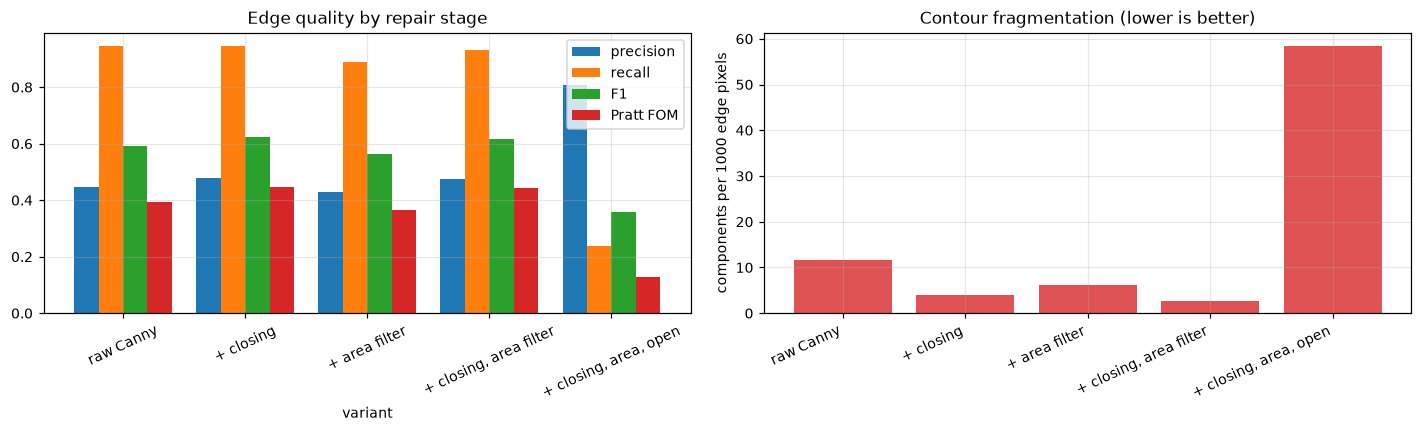

Closing plus area filtering moves F1 from 0.5918 to 0.6170 (+4.3%), while fragmentation falls from 11.7 to 2.7 per 1000 edge pixels.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ablation_table[["precision", "recall", "F1", "Pratt FOM"]].plot(
    kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Edge quality by repair stage")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(range(len(ablation_table)), ablation_table["fragmentation"],
            color="tab:red", alpha=0.8)
axes[1].set_xticks(range(len(ablation_table)))
axes[1].set_xticklabels(ablation_table.index, rotation=25, ha="right")
axes[1].set_ylabel("components per 1000 edge pixels")
axes[1].set_title("Contour fragmentation (lower is better)")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "C1_repair_ablation.png")
plt.show()

first = ablation_table.iloc[0]
best = ablation_table.loc["+ closing, area filter"]
print(f"Closing plus area filtering moves F1 from {first['F1']:.4f} to "
      f"{best['F1']:.4f} ({100 * (best['F1'] - first['F1']) / first['F1']:+.1f}%), "
      f"while fragmentation falls from {first['fragmentation']:.1f} to "
      f"{best['fragmentation']:.1f} per 1000 edge pixels.")

### C.2 Skeletonisation and spur pruning

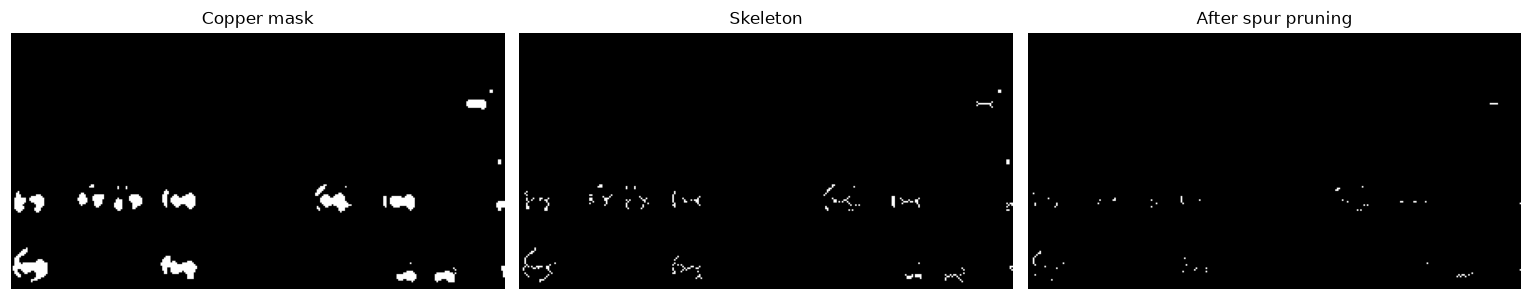

,n_components,edge_pixels,mean_component_size,fragmentation
stage,,,,
copper mask,413,36628,88.688,11.276
skeleton,960,10329,10.759,92.942
"skeleton, pruned",671,6257,9.325,107.240


In [16]:
labels = region_label_map(demo["board"], CFG)
copper = to_binary(labels == 2)

skeleton = morphological_skeleton(copper)
pruned = prune_spurs(skeleton, iterations=3)

stats = pd.DataFrame([
    {"stage": "copper mask", **edge_continuity(copper)},
    {"stage": "skeleton", **edge_continuity(skeleton)},
    {"stage": "skeleton, pruned", **edge_continuity(pruned)},
]).set_index("stage").round(3)

# A detail region, so that unit-width structure survives rasterisation.
h, w = copper.shape
detail = (slice(h // 4, h // 2), slice(w // 4, w // 2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (image, title) in zip(axes, [(copper[detail], "Copper mask"),
                                     (skeleton[detail], "Skeleton"),
                                     (pruned[detail], "After spur pruning")]):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
    ax.grid(False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "C2_skeleton.png")
plt.show()

stats

## 8 · Experiment D — Integration

The proposed pipeline measures the noise **once** and uses that single estimate
twice: to select the filter, and to set the Canny threshold floor.

The ablation below adds exactly one change per row, so the difference between
consecutive rows isolates that change's contribution.

In [17]:
PIPELINE_VARIANTS = {
    "1 Baseline (Gaussian + fixed Canny)":
        dict(smooth="gaussian", strategy="fixed", close=0, area=0),
    "2 + intensity-Otsu thresholds":
        dict(smooth="gaussian", strategy="otsu", close=0, area=0),
    "3 + gradient-domain thresholds":
        dict(smooth="gaussian", strategy="gradient", close=0, area=0),
    "4 + noise-scaled threshold floor":
        dict(smooth="gaussian", strategy="adaptive", close=0, area=0),
    "5 + morphological repair":
        dict(smooth="gaussian", strategy="adaptive", close=3, area=20),
    "6 Proposed (+ noise-adaptive filter)":
        dict(smooth="adaptive", strategy="adaptive", close=3, area=20),
    "7 Proposed with Sobel + Otsu":
        dict(smooth="adaptive", strategy=None, close=3, area=20, operator="sobel"),
}

records = []
for board_id, board in BOARDS.items():
    reference, gray = board["reference"], board["gray"]

    for noise_name, noise_fn, params in NOISE_CASES:
        degraded = gray if noise_fn is None else noise_fn(gray, **params)
        # Measured BEFORE smoothing, so the adaptive floor sees input noise.
        input_sigma = estimate_noise_sigma(degraded)

        for variant, settings in PIPELINE_VARIANTS.items():
            def run(image=degraded, s=settings, sigma=input_sigma):
                stage = smooth(image, s["smooth"], CFG)
                if s.get("operator"):
                    edges, _ = detect_edges(stage, s["operator"], CFG)
                else:
                    edges = edge_canny(stage, CFG, s["strategy"],
                                       noise_sigma=sigma)
                return repair_edge_map(edges, CFG,
                                       close_size=s["close"], min_area=s["area"])

            edges, elapsed = time_call(run, repeats=1)
            scores = evaluate_edge_map(edges, reference, CFG)
            records.append({"board": board_id, "noise": noise_name,
                            "variant": variant,
                            "precision": scores["precision"],
                            "recall": scores["recall"], "F1": scores["f1"],
                            "Pratt FOM": scores["pratt_fom"],
                            "time (ms)": elapsed})

pipeline = pd.DataFrame(records)
pipeline.to_csv(RESULT_DIR / "D_pipeline_comparison_raw.csv", index=False)

order = list(PIPELINE_VARIANTS)
grouped = pipeline.groupby("variant")
overall = pd.DataFrame({
    "F1 mean": grouped["F1"].mean(), "F1 std": grouped["F1"].std(),
    "FOM mean": grouped["Pratt FOM"].mean(),
    "FOM std": grouped["Pratt FOM"].std(),
    "precision": grouped["precision"].mean(),
    "recall": grouped["recall"].mean(),
    "time (ms)": grouped["time (ms)"].mean(),
}).reindex(order).round(4)
overall.to_csv(RESULT_DIR / "D_pipeline_summary.csv")
overall

,F1 mean,F1 std,FOM mean,FOM std,precision,recall,time (ms)
variant,,,,,,,
1 Baseline (Gaussian + fixed Canny),0.6220,0.1456,0.3470,0.0547,0.5248,0.8416,6.0598
2 + intensity-Otsu thresholds,0.4932,0.1656,0.3395,0.0929,0.3545,0.9448,7.6266
3 + gradient-domain thresholds,0.4958,0.1714,0.3459,0.1020,0.3553,0.9611,13.3777
4 + noise-scaled threshold floor,0.5962,0.1621,0.3647,0.0717,0.4873,0.9091,12.5231
5 + morphological repair,0.6252,0.1531,0.4137,0.0983,0.5209,0.9004,26.2114
6 Proposed (+ noise-adaptive filter),0.6615,0.1415,0.4193,0.1075,0.5750,0.8750,40.4403
7 Proposed with Sobel + Otsu,0.7310,0.1470,0.6220,0.1808,0.6366,0.9302,49.6733


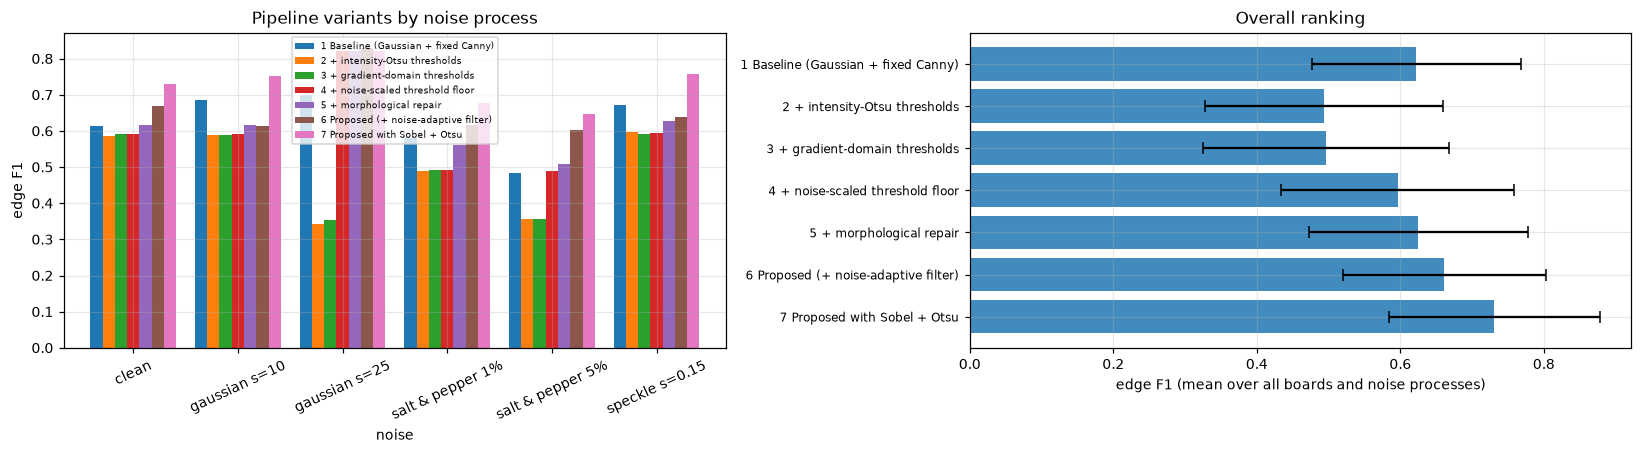

F1 mean    baseline 0.6220 -> best 0.7310  (+17.5% relative)
FOM mean   baseline 0.3470 -> best 0.6220  (+79.3% relative)

Best variant: 7 Proposed with Sobel + Otsu
Beats the baseline in 6 of 6 noise conditions.


variant,1 Baseline (Gaussian + fixed Canny),2 + intensity-Otsu thresholds,3 + gradient-domain thresholds,4 + noise-scaled threshold floor,5 + morphological repair,6 Proposed (+ noise-adaptive filter),7 Proposed with Sobel + Otsu
noise,,,,,,,
clean,0.613400,0.586600,0.591800,0.591800,0.617000,0.668000,0.730700
gaussian s=10,0.684700,0.589100,0.588200,0.591100,0.616000,0.613600,0.753200
gaussian s=25,0.700000,0.342800,0.354300,0.820700,0.821300,0.829800,0.820700
salt & pepper 1%,0.579600,0.488300,0.491500,0.491500,0.562300,0.617700,0.677200
salt & pepper 5%,0.483300,0.356100,0.356500,0.488400,0.507800,0.601200,0.647200
speckle s=0.15,0.671200,0.596500,0.592700,0.593600,0.626700,0.638500,0.756800
mean,0.622033,0.493233,0.495833,0.596183,0.625183,0.661467,0.730967


In [18]:
breakdown = (pipeline.pivot_table(index="noise", columns="variant", values="F1")
             .reindex(columns=order).round(4))
breakdown.loc["mean"] = breakdown.mean()
breakdown.to_csv(RESULT_DIR / "D_pipeline_by_noise.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))

breakdown.drop(index="mean").plot(kind="bar", ax=axes[0], width=0.82)
axes[0].set_ylabel("edge F1")
axes[0].set_title("Pipeline variants by noise process")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(fontsize=6)

axes[1].barh(range(len(overall)), overall["F1 mean"],
             xerr=overall["F1 std"], color="tab:blue", alpha=0.85, capsize=4)
axes[1].set_yticks(range(len(overall)))
axes[1].set_yticklabels(overall.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("edge F1 (mean over all boards and noise processes)")
axes[1].set_title("Overall ranking")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "D_pipeline_comparison.png")
plt.show()

baseline_key = "1 Baseline (Gaussian + fixed Canny)"
best_key = overall["F1 mean"].idxmax()

for metric in ["F1 mean", "FOM mean"]:
    base, best = overall.loc[baseline_key, metric], overall.loc[best_key, metric]
    print(f"{metric:9s}  baseline {base:.4f} -> best {best:.4f}  "
          f"({100 * (best - base) / base:+.1f}% relative)")

wins = (breakdown.drop(index="mean")[best_key]
        > breakdown.drop(index="mean")[baseline_key])
print(f"\nBest variant: {best_key}")
print(f"Beats the baseline in {int(wins.sum())} of {len(wins)} noise conditions.")
breakdown

## 9 · Chosen parameters

These are the values carried into `02_processed_dataset.ipynb`.

In [19]:
chosen = pd.DataFrame([
    {"config": "A1", "technique": "Gaussian", "setting": "light",
     "parameters": "ksize=3, sigma=0.8"},
    {"config": "A2", "technique": "Gaussian", "setting": "medium",
     "parameters": "ksize=5, sigma=1.5"},
    {"config": "A3", "technique": "Gaussian", "setting": "heavy",
     "parameters": "ksize=9, sigma=2.5"},
    {"config": "B1", "technique": "Canny edge", "setting": "weak",
     "parameters": "low=100, high=200, weight=0.3"},
    {"config": "B2", "technique": "Canny edge", "setting": "medium",
     "parameters": "low=50, high=150, weight=0.5"},
    {"config": "B3", "technique": "Canny edge", "setting": "strong",
     "parameters": "low=30, high=90, weight=0.7"},
    {"config": "C1", "technique": "Morphological", "setting": "small",
     "parameters": "ksize=5"},
    {"config": "C2", "technique": "Morphological", "setting": "medium",
     "parameters": "ksize=15"},
    {"config": "C3", "technique": "Morphological", "setting": "large",
     "parameters": "ksize=25"},
])
chosen.to_csv(RESULT_DIR / "chosen_parameters.csv", index=False)

print("Artefacts written to", RESULT_DIR)
for path in sorted(RESULT_DIR.rglob("*")):
    if path.is_file():
        print("   ", path.relative_to(RESULT_DIR))

chosen

Artefacts written to e:\SCHOOL\DEGY3S1\Image Processing\PCB-Defect-Inspection\results\structural_enhancement
    A2_gaussian_parameter_sweep.csv
    C1_repair_ablation.csv
    chosen_parameters.csv
    D_pipeline_by_noise.csv
    D_pipeline_comparison_raw.csv
    D_pipeline_summary.csv
    figures\01_reference_map.png
    figures\A2_gaussian_sweep.png
    figures\C1_repair_ablation.png
    figures\C2_skeleton.png
    figures\D_pipeline_comparison.png


,config,technique,setting,parameters
0,A1,Gaussian,light,"ksize=3, sigma=0.8"
1,A2,Gaussian,medium,"ksize=5, sigma=1.5"
2,A3,Gaussian,heavy,"ksize=9, sigma=2.5"
3,B1,Canny edge,weak,"low=100, high=200, weight=0.3"
4,B2,Canny edge,medium,"low=50, high=150, weight=0.5"
5,B3,Canny edge,strong,"low=30, high=90, weight=0.7"
6,C1,Morphological,small,ksize=5
7,C2,Morphological,medium,ksize=15
8,C3,Morphological,large,ksize=25


## 10 · Findings

**Gaussian filtering.** Restoration quality peaks at a small kernel: enlarging
the kernel or sigma beyond that continues to raise PSNR while the edge
preservation index falls, confirming PSNR alone is inadequate for an inspection
task. On an undegraded board the best filter is *no* filter, so smoothing must
be conditional on the noise actually present. The ranking is not constant
across noise processes — median leads under impulse noise, bilateral under
strong additive noise — which is what motivates selecting per image.

**Edge detection.** Canny thresholds must be set in the **gradient domain**.
The ablation shows intensity-domain Otsu is measurably *worse* than fixed
thresholds, because Canny compares against gradient magnitude, not intensity.
Moving to the gradient domain recovers little on its own; the noise-scaled
floor restores the loss, decisively under strong additive noise.

**Morphological processing.** The repair stage is the largest single
contributor to contour quality. Closing followed by area filtering raises F1
while cutting fragmentation by roughly an order of magnitude. The optional
opening is actively harmful — a 3×3 opening deletes contours only one pixel
wide, collapsing F1 — and is therefore disabled.

**Integration.** Read the ranking in section 8 rather than assuming a winner:
on this reference the Otsu-binarised gradient operators are competitive with
Canny, and part of any lead they show is thickness compatibility rather than
better localisation. Both raw and thickness-normalised scoring are available
via `evaluate_edge_map(..., normalise_thickness=True)` for that reason.

**Limitations to state in the report.**

1. *Reference bias.* Silkscreen and solder-mask texture are genuine intensity
   edges the colour-derived reference does not contain, so absolute precision
   is a lower bound and heavy blurring is rewarded beyond its structural merit.
   The bias is identical across methods, so the ranking holds.
2. *Thickness sensitivity.* Overlap metrics reward maps whose thickness
   resembles the reference.
3. *Simulated noise.* The noise processes are synthetic — controlled and
   repeatable, but possibly unlike real acquisition noise.
4. *Defect-free boards only.* Measurements use `PCB_USED`. Whether these
   parameters actually improve *detection* is settled by
   `03_run_comparison.ipynb`, not here.